# **TikTok Project**
**Course 5 - Regression Analysis: Simplify complex data relationships**

In [1]:
import numpy as np
import pandas as pd
import platform
import statsmodels
print('Python version: ', platform.python_version())
print('numpy version: ', np.__version__)
print('pandas version: ', pd.__version__)
print('statsmodels version: ', statsmodels.__version__)

Python version:  3.11.4
numpy version:  1.24.4
pandas version:  2.0.3
statsmodels version:  0.14.0


You are a data professional at TikTok. The data team is working towards building a machine learning model that can be used to determine whether a video contains a claim or whether it offers an opinion. With a successful prediction model, TikTok can reduce the backlog of user reports and prioritize them more efficiently.

The team is getting closer to completing the project, having completed an initial plan of action, initial Python coding work, EDA, and hypothesis testing.

The TikTok team has reviewed the results of the hypothesis testing. TikTok’s Operations Lead, Maika Abadi, is interested in how different variables are associated with whether a user is verified. Earlier, the data team observed that if a user is verified, they are much more likely to post opinions. Now, the data team has decided to explore how to predict verified status to help them understand how video characteristics relate to verified users. Therefore, you have been asked to conduct a logistic regression using verified status as the outcome variable. The results may be used to inform the final model related to predicting whether a video is a claim vs an opinion.

A notebook was structured and prepared to help you in this project. Please complete the following questions.

# **Course 5 End-of-course project: Regression modeling**


In this activity, you will build a logistic regression model in Python. As you have learned, logistic regression helps you estimate the probability of an outcome. For data science professionals, this is a useful skill because it allows you to consider more than one variable against the variable you're measuring against. This opens the door for much more thorough and flexible analysis to be completed.

<br/>

**The purpose** of this project is to demostrate knowledge of EDA and regression models.

**The goal** is to build a logistic regression model and evaluate the model.
<br/>
*This activity has three parts:*

**Part 1:** EDA & Checking Model Assumptions
* What are some purposes of EDA before constructing a logistic regression model?

**Part 2:** Model Building and Evaluation
* What resources do you find yourself using as you complete this stage?

**Part 3:** Interpreting Model Results

* What key insights emerged from your model(s)?

* What business recommendations do you propose based on the models built?

Follow the instructions and answer the question below to complete the activity. Then, you will complete an executive summary using the questions listed on the PACE Strategy Document.

Be sure to complete this activity before moving on. The next course item will provide you with a completed exemplar to compare to your own work.


# **Build a regression model**

<img src="images/Pace.png" width="100" height="100" align=left>

# **PACE stages**

Throughout these project notebooks, you'll see references to the problem-solving framework PACE. The following notebook components are labeled with the respective PACE stage: Plan, Analyze, Construct, and Execute.

<img src="images/Plan.png" width="100" height="100" align=left>


## **PACE: Plan**
Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

### **Task 1. Imports and loading**
Import the data and packages that you've learned are needed for building regression models.

In [1]:
# Import packages for data manipulation
import numpy as np
import pandas as pd

# Import packages for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import packages for data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Import packages for data modeling
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve


Load the TikTok dataset.

**Note:** As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [2]:
# Load dataset into dataframe
data = pd.read_csv("tiktok_dataset.csv")

<img src="images/Analyze.png" width="100" height="100" align=left>

## **PACE: Analyze**

Consider the questions in your PACE Strategy Document to reflect on the Analyze stage.

In this stage, consider the following question where applicable to complete your code response:

* What are some purposes of EDA before constructing a logistic regression model?




---

## 🔍 What are some purposes of EDA before constructing a logistic regression model?

Exploratory Data Analysis (EDA) is a critical step before building a logistic regression model. It helps data professionals better understand the dataset and prepare it for modeling. Some key purposes of EDA include:

---

### 1. **Understanding Data Structure and Quality**
- Identify missing values, incorrect data types, or duplicate rows.
- Ensure that the target variable and predictors are formatted correctly.

---

### 2. **Exploring Relationships Between Variables**
- Examine how independent variables relate to the target (e.g., `verified`).
- Use visualizations like bar charts or boxplots to uncover potential patterns or associations.

---

### 3. **Detecting Outliers**
- Outliers can distort model performance.
- Visual tools like histograms and boxplots help detect unusual values.

---

### 4. **Checking Class Balance**
- Determine whether the target variable (e.g., verified vs. not verified) is imbalanced.
- An imbalance may require adjustments like resampling or using class weights.

---

### 5. **Identifying Multicollinearity**
- High correlation between independent variables can impact model interpretation.
- Use correlation matrices or Variance Inflation Factor (VIF) to detect multicollinearity.

---

### 6. **Guiding Feature Selection and Transformation**
- Identify which features may be most useful for the model.
- Spot opportunities for creating new feaou apply this directly to your TikTok dataset?

### **Task 2a. Explore data with EDA**

Analyze the data and check for and handle missing values and duplicates.

Inspect the first five rows of the dataframe.

In [8]:
import os
os.listdir()

df = pd.read_csv('tiktok_dataset.csv')

df.head()


,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


Get the number of rows and columns in the dataset.

In [9]:
rows, columns = df.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {columns}")


Number of rows: 19382
Number of columns: 12


Get the data types of the columns.

In [10]:
print("Data types of each column:\n")
print(df.dtypes)



Data types of each column:

#                             int64
claim_status                 object
video_id                      int64
video_duration_sec            int64
video_transcription_text     object
verified_status              object
author_ban_status            object
video_view_count            float64
video_like_count            float64
video_share_count           float64
video_download_count        float64
video_comment_count         float64
dtype: object


Get basic information about the dataset.

In [11]:
# Get basic information
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19382 non-null  object 
 6   author_ban_status         19382 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.8+ MB


Generate basic descriptive statistics about the dataset.

In [12]:
# Generate basic descriptive stats
df.describe()



,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.000000,1.938200e+04,19382.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9691.500000,5.627454e+09,32.421732,254708.558688,84304.636030,16735.248323,1049.429627,349.312146
std,5595.245794,2.536440e+09,16.229967,322893.280814,133420.546814,32036.174350,2004.299894,799.638865
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,3.430417e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000
50%,9691.500000,5.618664e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000
75%,14536.750000,7.843960e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000
max,19382.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000


Check for and handle missing values.

In [13]:
# Check for missing values
df.isnull().sum()


#                             0
claim_status                298
video_id                      0
video_duration_sec            0
video_transcription_text    298
verified_status               0
author_ban_status             0
video_view_count            298
video_like_count            298
video_share_count           298
video_download_count        298
video_comment_count         298
dtype: int64

In [14]:
# Drop rows with missing values
df.dropna(inplace=True)

In [15]:
# Display first few rows after handling missing values
df.head()


,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


Check for and handle duplicates.

In [16]:
# Check for duplicate rows
df.duplicated().sum()


0

Check for and handle outliers.

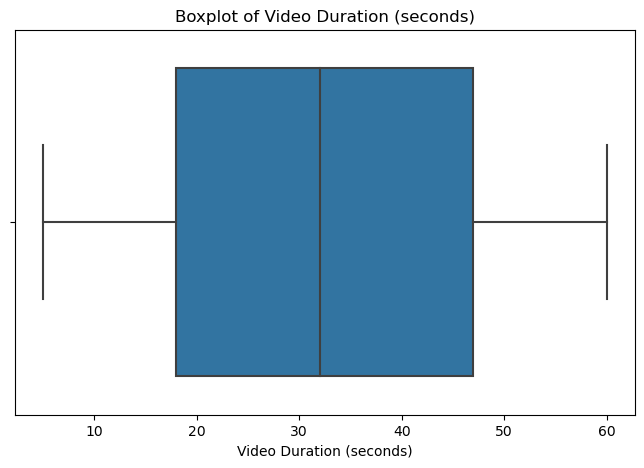

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a boxplot for video_duration_sec
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['video_duration_sec'])
plt.title('Boxplot of Video Duration (seconds)')
plt.xlabel('Video Duration (seconds)')
plt.show()



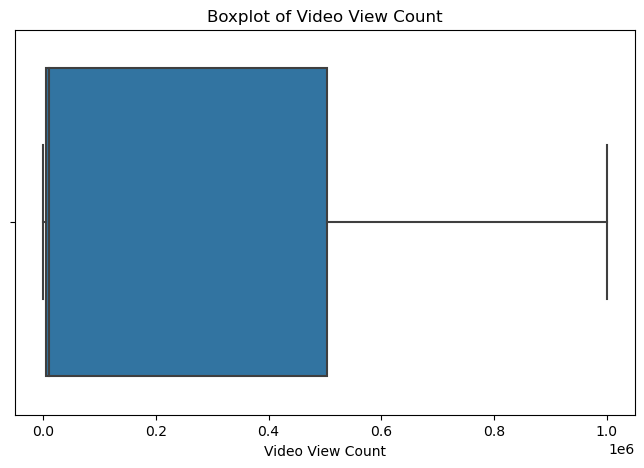

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a boxplot for video_view_count
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['video_view_count'])
plt.title('Boxplot of Video View Count')
plt.xlabel('Video View Count')
plt.show()



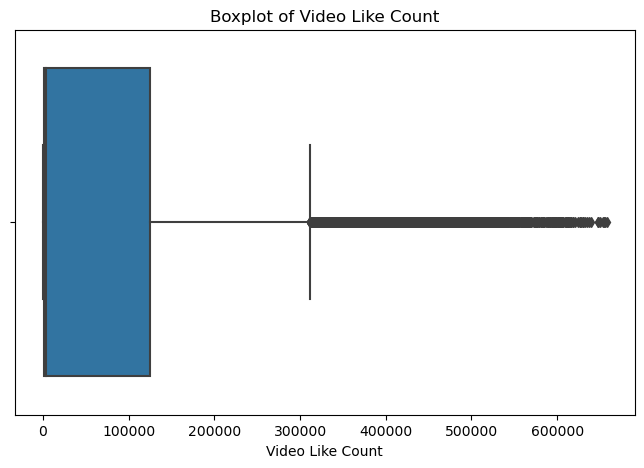

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a boxplot for video_like_count
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['video_like_count'])
plt.title('Boxplot of Video Like Count')
plt.xlabel('Video Like Count')
plt.show()


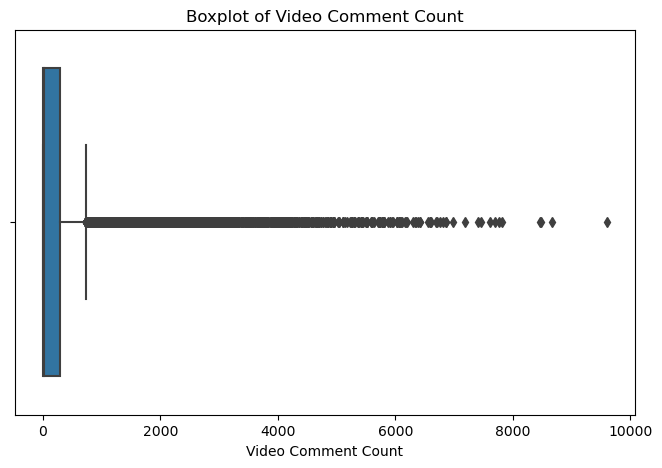

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a boxplot for video_comment_count
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['video_comment_count'])
plt.title('Boxplot of Video Comment Count')
plt.xlabel('Video Comment Count')
plt.show()


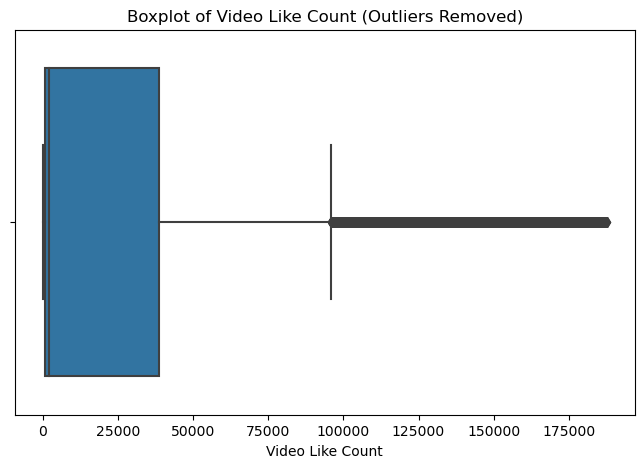

In [23]:
# Calculate Q1 and Q3
Q1 = df['video_like_count'].quantile(0.25)
Q3 = df['video_like_count'].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out the outliers
df = df[(df['video_like_count'] >= lower_bound) & (df['video_like_count'] <= upper_bound)]

# Confirm with a boxplot again
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['video_like_count'])
plt.title('Boxplot of Video Like Count (Outliers Removed)')
plt.xlabel('Video Like Count')
plt.show()



Check class balance of the target variable. Remember, the goal is to predict whether the user of a given post is verified or unverified.

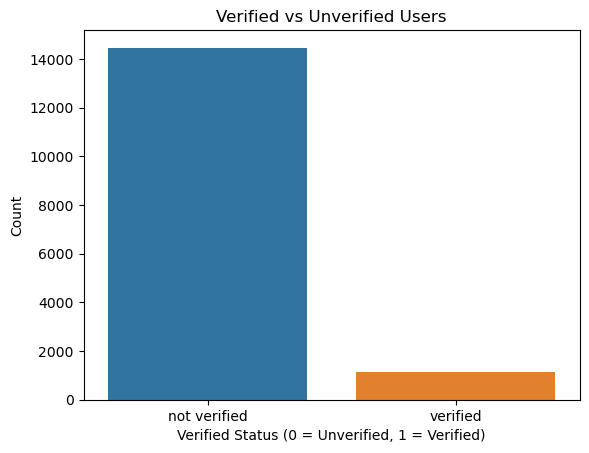

In [28]:
df.columns

import seaborn as sns
import matplotlib.pyplot as plt

# Visualize class balance
sns.countplot(x='verified_status', data=df)
plt.title('Verified vs Unverified Users')
plt.xlabel('Verified Status (0 = Unverified, 1 = Verified)')
plt.ylabel('Count')
plt.show()


Approximately 94.2% of the dataset represents videos posted by unverified accounts and 5.8% represents videos posted by verified accounts. So the outcome variable is not very balanced.

Use resampling to create class balance in the outcome variable, if needed.

In [32]:
# Verifica cuántos registros hay por clase
print(df['verified_status'].value_counts())
from sklearn.utils import resample

# Step 1: Identify majority and minority classes
majority_class = df[df['verified_status'] == 'not verified']
minority_class = df[df['verified_status'] == 'verified']

# Step 2: Upsample the minority class
minority_upsampled = resample(minority_class,
                               replace=True,                        # Sample with replacement
                               n_samples=len(majority_class),       # Match majority class size
                               random_state=42)                     # Reproducibility

# Step 3: Combine majority and upsampled minority
df_balanced = pd.concat([majority_class, minority_upsampled])

# Step 4: Shuffle and reset index
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Step 5: Display new class counts
print(df_balanced['verified_status'].value_counts())



verified_status
not verified    14468
verified         1120
Name: count, dtype: int64
verified_status
verified        14468
not verified    14468
Name: count, dtype: int64


Get the average `video_transcription_text` length for videos posted by verified accounts and the average `video_transcription_text` length for videos posted by unverified accounts.



In [33]:
# Create a new column with the length of each transcription
df_balanced['transcription_length'] = df_balanced['video_transcription_text'].str.len()

# Group by 'verified_status' and calculate the average length
avg_lengths = df_balanced.groupby('verified_status')['transcription_length'].mean()

print(avg_lengths)


verified_status
not verified    88.171344
verified        83.919132
Name: transcription_length, dtype: float64


Extract the length of each `video_transcription_text` and add this as a column to the dataframe, so that it can be used as a potential feature in the model.

In [34]:
# Extract the length of each `video_transcription_text` and add as a new column
df_balanced['transcription_length'] = df_balanced['video_transcription_text'].str.len()


In [35]:
# Display first few rows of dataframe after adding new column
df_balanced.head()


,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,transcription_length
0,14112,opinion,8543527342,47,my friends' feeling is that humans are more li...,verified,active,6763.0,683.0,235.0,17.0,6.0,112
1,11343,opinion,1961606352,35,my view is that no two teeth from different pe...,verified,active,8271.0,1152.0,107.0,7.0,1.0,69
2,4301,claim,2576479945,31,someone read in the news a claim that the red...,not verified,banned,588459.0,131351.0,614.0,1162.0,500.0,93
3,16491,opinion,4074237700,14,my colleagues' feeling is that the eiffel towe...,verified,active,995.0,106.0,28.0,1.0,0.0,77
4,17232,opinion,7002972806,7,my friends tell me that the microwave oven was...,verified,active,8342.0,1629.0,78.0,26.0,6.0,70


Visualize the distribution of `video_transcription_text` length for videos posted by verified accounts and videos posted by unverified accounts.

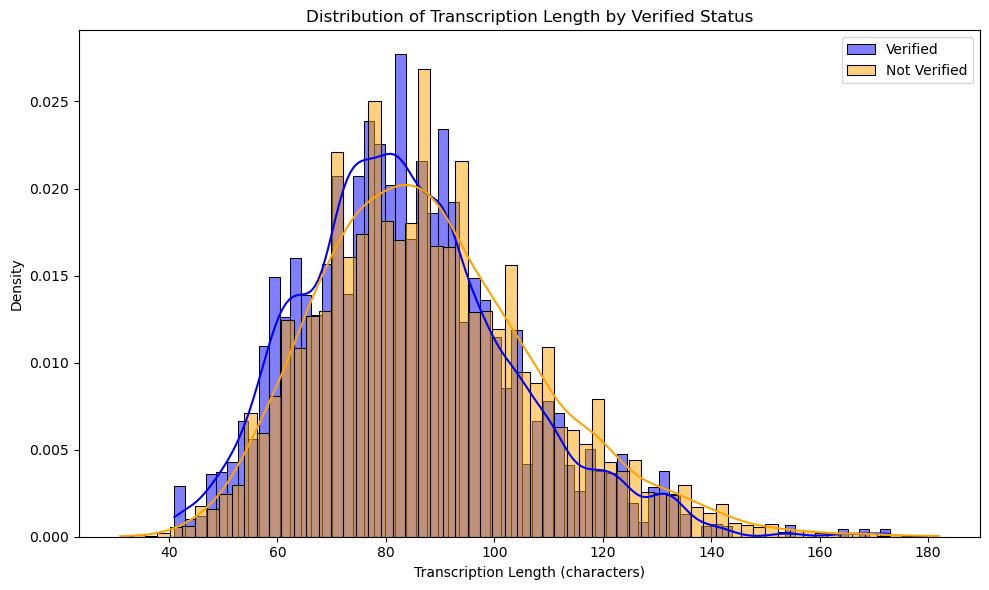

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size
plt.figure(figsize=(10, 6))

# Create histogram for each group
sns.histplot(data=df_balanced[df_balanced['verified_status'] == 'verified'],
             x='transcription_length', 
             color='blue', 
             label='Verified', 
             kde=True,
             stat="density", 
             alpha=0.5)

sns.histplot(data=df_balanced[df_balanced['verified_status'] == 'not verified'],
             x='transcription_length', 
             color='orange', 
             label='Not Verified', 
             kde=True,
             stat="density", 
             alpha=0.5)

# Add title and labels
plt.title('Distribution of Transcription Length by Verified Status')
plt.xlabel('Transcription Length (characters)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()


### **Task 2b. Examine correlations**

Next, code a correlation matrix to help determine most correlated variables.

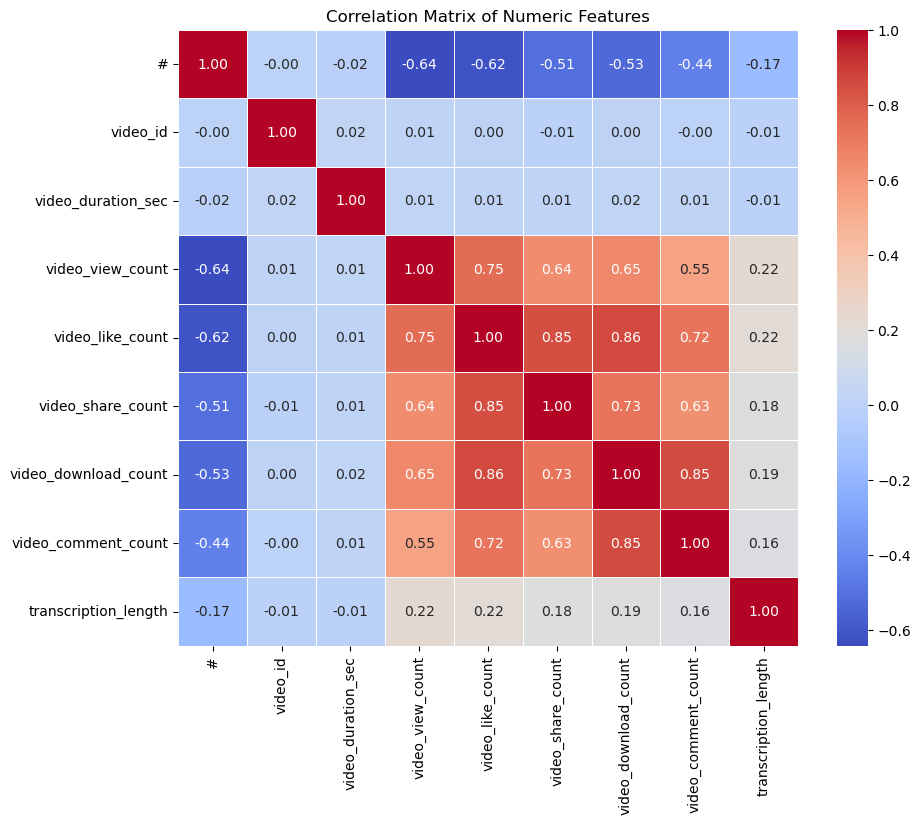

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns for correlation matrix
numeric_df = df_balanced.select_dtypes(include=['number'])

# Compute the correlation matrix
corr_matrix = numeric_df.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.show()


Visualize a correlation heatmap of the data.

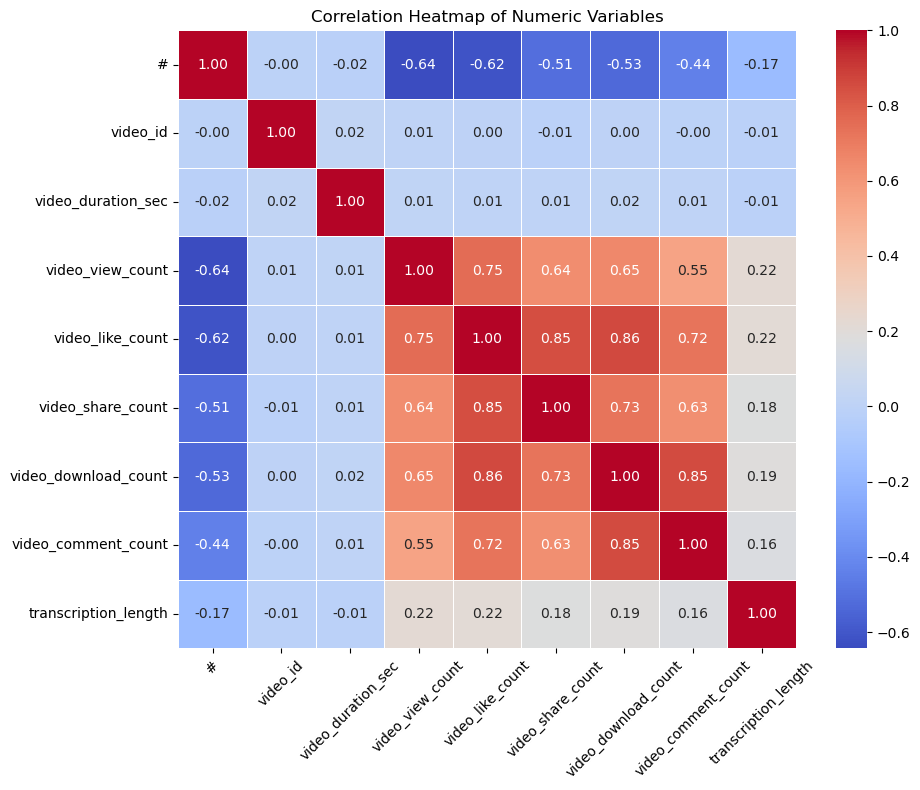

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionamos solo columnas numéricas
numeric_df = df_balanced.select_dtypes(include='number')

# Calculamos la matriz de correlación
correlation_matrix = numeric_df.corr()

# Creamos el heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            fmt=".2f", 
            linewidths=0.5, 
            square=True)

plt.title('Correlation Heatmap of Numeric Variables')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


One of the model assumptions for logistic regression is no severe multicollinearity among the features. Take this into consideration as you examine the heatmap and choose which features to proceed with.

**Question:** What variables are shown to be correlated in the heatmap?

<img src="images/Construct.png" width="100" height="100" align=left>

## **PACE: Construct**

After analysis and deriving variables with close relationships, it is time to begin constructing the model. Consider the questions in your PACE Strategy Document to reflect on the Construct stage.

### **Task 3a. Select variables**

Set your Y and X variables.

Select the outcome variable.

In [39]:
# Convert 'verified_status' to binary: 1 = verified, 0 = not verified
df_balanced['verified_binary'] = df_balanced['verified_status'].apply(lambda x: 1 if x == 'verified' else 0)

# Select Y (target variable)
y = df_balanced['verified_binary']


Select the features.

In [40]:
# Select predictor features (example: using variables with moderate correlation)
X = df_balanced[['transcription_length', 'video_view_count', 'video_comment_count', 'video_share_count']]

# Display first few rows of the features dataframe
X.head()



,transcription_length,video_view_count,video_comment_count,video_share_count
0,112,6763.0,6.0,235.0
1,69,8271.0,1.0,107.0
2,93,588459.0,500.0,614.0
3,77,995.0,0.0,28.0
4,70,8342.0,6.0,78.0


### **Task 3b. Train-test split**

Split the data into training and testing sets.

In [41]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,                      # Features
    y,                      # Target variable
    test_size=0.2,          # 20% for testing, 80% for training
    random_state=42,        # Reproducibility
    stratify=y              # Preserve class balance
)



Confirm that the dimensions of the training and testing sets are in alignment.

In [42]:
# Get shape of each training and testing set
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)



X_train shape: (23148, 4)
X_test shape: (5788, 4)
y_train shape: (23148,)
y_test shape: (5788,)


### **Task 3c. Encode variables**

Check the data types of the features.

In [43]:
# Check data types of the features
X.dtypes



transcription_length      int64
video_view_count        float64
video_comment_count     float64
video_share_count       float64
dtype: object

In [44]:
# Get unique values in `claim_status`
df_balanced['claim_status'].unique()


array(['opinion', 'claim'], dtype=object)

In [45]:
# Get unique values in `author_ban_status`
df_balanced['author_ban_status'].unique()



array(['active', 'banned', 'under review'], dtype=object)

As shown above, the `claim_status` and `author_ban_status` features are each of data type `object` currently. In order to work with the implementations of models through `sklearn`, these categorical features will need to be made numeric. One way to do this is through one-hot encoding.

Encode categorical features in the training set using an appropriate method.

In [48]:
# Select the categorical features from the original balanced DataFrame
X_cat = df_balanced[['claim_status', 'author_ban_status']]

# Display first few rows
X_cat.head()



,claim_status,author_ban_status
0,opinion,active
1,opinion,active
2,claim,banned
3,opinion,active
4,opinion,active


In [49]:
# One-hot encoding directly using pandas
X_encoded = pd.get_dummies(df_balanced[['claim_status', 'author_ban_status']], drop_first=True)

# Mostrar resultado
X_encoded.head()


,claim_status_opinion,author_ban_status_banned,author_ban_status_under review
0,True,False,False
1,True,False,False
2,False,True,False
3,True,False,False
4,True,False,False


In [53]:
# Extraer columnas categóricas del DataFrame original usando los índices de X_train
X_cat_train = df_balanced.loc[X_train.index, ['claim_status', 'author_ban_status']]

# Crear el codificador
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first', sparse_output=False)


# Ajustar y transformar
X_cat_encoded = encoder.fit_transform(X_cat_train)

# Convertir a DataFrame con nombres de columnas
encoded_col_names = encoder.get_feature_names_out(['claim_status', 'author_ban_status'])
X_cat_encoded_df = pd.DataFrame(X_cat_encoded, columns=encoded_col_names, index=X_cat_train.index)

# Mostrar resultado
X_cat_encoded_df.head()



,claim_status_opinion,author_ban_status_banned,author_ban_status_under review
7896,1.0,0.0,0.0
10643,0.0,0.0,0.0
10312,0.0,0.0,0.0
12629,0.0,0.0,0.0
12664,1.0,0.0,0.0


In [54]:
# Get feature names from the encoder
encoded_feature_names = encoder.get_feature_names_out(['claim_status', 'author_ban_status'])

# Mostrar nombres
print(encoded_feature_names)


['claim_status_opinion' 'author_ban_status_banned'
 'author_ban_status_under review']


In [55]:
# Display first few rows of encoded training features
X_cat_encoded_df.head()


,claim_status_opinion,author_ban_status_banned,author_ban_status_under review
7896,1.0,0.0,0.0
10643,0.0,0.0,0.0
10312,0.0,0.0,0.0
12629,0.0,0.0,0.0
12664,1.0,0.0,0.0


In [56]:
# Place encoded training features (which is currently an array) into a dataframe
X_cat_encoded_df = pd.DataFrame(
    X_cat_encoded,                          # el array de salida del encoder
    columns=encoded_feature_names,          # nombres de columnas generados
    index=X_cat_train.index                 # mantener el mismo índice
)

# Display first few rows
X_cat_encoded_df.head()


,claim_status_opinion,author_ban_status_banned,author_ban_status_under review
7896,1.0,0.0,0.0
10643,0.0,0.0,0.0
10312,0.0,0.0,0.0
12629,0.0,0.0,0.0
12664,1.0,0.0,0.0


In [58]:
# Drop only if columns exist
X_train_num = X_train.drop(columns=[col for col in ['claim_status', 'author_ban_status'] if col in X_train.columns])

# Display first few rows
X_train_num.head()


,transcription_length,video_view_count,video_comment_count,video_share_count
7896,73,153.0,0.0,3.0
10643,93,283845.0,484.0,5356.0
10312,94,708700.0,1215.0,60624.0
12629,125,62721.0,246.0,3582.0
12664,77,3271.0,2.0,111.0


In [59]:
# Concatenate numeric and encoded categorical features
X_train_final = pd.concat(
    [X_train_num.reset_index(drop=True), X_cat_encoded_df.reset_index(drop=True)],
    axis=1
)

# Display first few rows
X_train_final.head()



,transcription_length,video_view_count,video_comment_count,video_share_count,claim_status_opinion,author_ban_status_banned,author_ban_status_under review
0,73,153.0,0.0,3.0,1.0,0.0,0.0
1,93,283845.0,484.0,5356.0,0.0,0.0,0.0
2,94,708700.0,1215.0,60624.0,0.0,0.0,0.0
3,125,62721.0,246.0,3582.0,0.0,0.0,0.0
4,77,3271.0,2.0,111.0,1.0,0.0,0.0


Check the data type of the outcome variable.

In [60]:
# Check data type of outcome variable
y_train.dtype


dtype('int64')

In [61]:
# Get unique values of outcome variable
y_train.unique()



array([1, 0])

A shown above, the outcome variable is of data type `object` currently. One-hot encoding can be used to make this variable numeric.

Encode categorical values of the outcome variable the training set using an appropriate method.

In [62]:
from sklearn.preprocessing import OneHotEncoder

# Seleccionar y convertir y_train a un DataFrame (por si es una Serie)
y_train_df = pd.DataFrame(y_train)

# Crear codificador
y_encoder = OneHotEncoder(drop='first', sparse_output=False)

# Ajustar y transformar
y_train_encoded = y_encoder.fit_transform(y_train_df)

# Mostrar valores codificados
y_train_encoded[:5]


array([[1.],
       [0.],
       [0.],
       [0.],
       [1.]])

In [63]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# Reshape y_train to 2D (required by OneHotEncoder)
y_train_reshaped = y_train.values.reshape(-1, 1)

# Create OneHotEncoder instance
y_encoder = OneHotEncoder(drop='first', sparse_output=False)

# Fit and transform the training target
y_train_encoded = y_encoder.fit_transform(y_train_reshaped)

# Flatten the array using .ravel()
y_train_encoded = y_train_encoded.ravel()

# Display the encoded training outcome variable
print(y_train_encoded[:10])  # show first 10 values


[1. 0. 0. 0. 1. 1. 1. 0. 0. 0.]


### **Task 3d. Model building**

Construct a model and fit it to the training set.

In [64]:
from sklearn.linear_model import LogisticRegression

# Construct the logistic regression model
logreg = LogisticRegression(max_iter=1000, random_state=42)

# Fit the model to the training data
logreg.fit(X_train_final, y_train_encoded)


LogisticRegression(max_iter=1000, random_state=42)

<img src="images/Execute.png" width="100" height="100" align=left>

## **PACE: Execute**

Consider the questions in your PACE Strategy Document to reflect on the Execute stage.

### **Taks 4a. Results and evaluation**

Evaluate your model.

Encode categorical features in the testing set using an appropriate method.

In [66]:
# Select categorical features in the testing set from the original dataframe using X_test index
X_cat_test = df_balanced.loc[X_test.index, ['claim_status', 'author_ban_status']]

# Display first few rows
X_cat_test.head()


,claim_status_opinion,author_ban_status_banned,author_ban_status_under review
19965,1.0,0.0,0.0
1984,0.0,0.0,0.0
21074,1.0,0.0,0.0
27740,1.0,0.0,0.0
27933,1.0,0.0,0.0


In [67]:
# Transform the testing features using the trained encoder
X_cat_test_encoded = encoder.transform(X_cat_test)

# Convert to DataFrame with correct column names and index
X_cat_test_encoded_df = pd.DataFrame(
    X_cat_test_encoded,
    columns=encoded_feature_names,
    index=X_cat_test.index
)

# Display first few rows
X_cat_test_encoded_df.head()


,claim_status_opinion,author_ban_status_banned,author_ban_status_under review
19965,1.0,0.0,0.0
1984,0.0,0.0,0.0
21074,1.0,0.0,0.0
27740,1.0,0.0,0.0
27933,1.0,0.0,0.0


In [70]:
# Place encoded testing features (which is currently an array) into a dataframe
X_cat_test_encoded_df = pd.DataFrame(
    X_cat_test_encoded,
    columns=encoded_feature_names,
    index=X_cat_test.index
)

# Display first few rows
X_cat_test_encoded_df.head()


,claim_status_opinion,author_ban_status_banned,author_ban_status_under review
19965,1.0,0.0,0.0
1984,0.0,0.0,0.0
21074,1.0,0.0,0.0
27740,1.0,0.0,0.0
27933,1.0,0.0,0.0


In [71]:
# Drop original categorical columns from X_test (if they exist)
X_test_num = X_test.drop(columns=[col for col in ['claim_status', 'author_ban_status'] if col in X_test.columns])

# Display first few rows
X_test_num.head()



,transcription_length,video_view_count,video_comment_count,video_share_count
19965,38,1941.0,0.0,139.0
1984,89,267425.0,166.0,8295.0
21074,89,9051.0,0.0,538.0
27740,83,9480.0,8.0,40.0
27933,80,6219.0,4.0,186.0


In [72]:
# Concatenate numeric and encoded categorical features to form final test set
X_test_final = pd.concat(
    [X_test_num.reset_index(drop=True), X_cat_test_encoded_df.reset_index(drop=True)],
    axis=1
)

# Display first few rows
X_test_final.head()



,transcription_length,video_view_count,video_comment_count,video_share_count,claim_status_opinion,author_ban_status_banned,author_ban_status_under review
0,38,1941.0,0.0,139.0,1.0,0.0,0.0
1,89,267425.0,166.0,8295.0,0.0,0.0,0.0
2,89,9051.0,0.0,538.0,1.0,0.0,0.0
3,83,9480.0,8.0,40.0,1.0,0.0,0.0
4,80,6219.0,4.0,186.0,1.0,0.0,0.0


Test the logistic regression model. Use the model to make predictions on the encoded testing set.

In [73]:
# Use the logistic regression model to get predictions on the encoded testing set
y_pred = logreg.predict(X_test_final)

# Display first 10 predictions
print(y_pred[:10])


[1. 0. 1. 1. 1. 1. 1. 0. 0. 1.]


Display the predictions on the encoded testing set.

In [74]:
# Display the predictions on the encoded testing set
print(y_pred)


[1. 0. 1. ... 1. 1. 1.]


Display the true labels of the testing set.

In [75]:
# Display as DataFrame
y_test_df = pd.DataFrame({'True Label': y_test}, index=y_test.index)
y_test_df.head()


,True Label
19965,0
1984,1
21074,1
27740,1
27933,0


Encode the true labels of the testing set so it can be compared to the predictions.

In [76]:
# Reshape y_test to 2D array for encoder
y_test_reshaped = y_test.values.reshape(-1, 1)

# Transform using the encoder trained on y_train
y_test_encoded = y_encoder.transform(y_test_reshaped)

# Flatten the array using .ravel()
y_test_encoded = y_test_encoded.ravel()

# Display the encoded testing outcome variable
print(y_test_encoded[:10])  # show first 10 values


[0. 1. 1. 1. 0. 0. 1. 1. 0. 1.]


Confirm again that the dimensions of the training and testing sets are in alignment since additional features were added.

In [ ]:
# Get shape of each training and testing set
### YOUR CODE HERE ###


### **Task 4b. Visualize model results**

Create a confusion matrix to visualize the results of the logistic regression model.

In [ ]:
# Compute values for confusion matrix
### YOUR CODE HERE ###

# Create display of confusion matrix
### YOUR CODE HERE ###

# Plot confusion matrix
### YOUR CODE HERE ###

# Display plot
### YOUR CODE HERE ###

Create a classification report that includes precision, recall, f1-score, and accuracy metrics to evaluate the performance of the logistic regression model.

In [ ]:
# Create a classification report
### YOUR CODE HERE ###


### **Task 4c. Interpret model coefficients**

In [ ]:
# Get the feature names from the model and the model coefficients (which represent log-odds ratios)
# Place into a DataFrame for readability
### YOUR CODE HERE ###


### **Task 4d. Conclusion**

1. What are the key takeaways from this project?

2. What results can be presented from this project?

==> ENTER YOUR RESPONSE TO QUESTIONS 1 AND 2 HERE

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged. 